# 0- Project Explanation 

This notebook is a **Strategic Growth Audit** designed for a **$990 consulting engagement**.

**Goal:** Transform raw transactional data into a complete strategic dossier with predictive insights, cohort retention, and a 100-day action plan.

**Data Period:** December 2010 – December 2011.

**Workflow:**
1. EDA (No Guessing)
2. Professional Cleaning + Explicit IQR Outlier Removal
3. Feature Engineering
4. 50+ Core KPIs + Strategic Charts (plotted immediately where data is available)
5. Advanced RFM Segmentation + Pie Chart
6. Cohort Retention Analysis + Heatmap
7. Advanced Basket Analysis (Apriori)
8. Summary & Next Steps

**Instructions:** Run every cell sequentially. After running, copy ALL printed tables and chart images to send to your consultant.

In [1]:
# CELL 1: IMPORT LIBRARIES & LOAD DATA (SUPPORTS XLSX / CSV)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# --- Install openpyxl if missing (for Excel files) ---
try:
    import openpyxl
except ImportError:
    print("📦 Installing openpyxl for Excel support...")
    !pip install openpyxl -q
    import openpyxl
    print("✅ openpyxl installed.")

# --- Install mlxtend for basket analysis ---
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    print("📦 Installing mlxtend...")
    !pip install mlxtend -q
    from mlxtend.frequent_patterns import apriori, association_rules

# Professional visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# --- LOAD FILE (AUTO-DETECT FORMAT) ---
# IMPORTANT: Change 'online_retail.xlsx' to your actual file name.
file_path = '/Users/esfandiar/Desktop/Data-Analyst-Projects/1-Online Retail/Online-Retail.xlsx'  # <--- SET YOUR FILE NAME HERE

if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
    df_raw = pd.read_excel(file_path, engine='openpyxl')
else:
    df_raw = pd.read_csv(file_path, encoding='unicode_escape')

print("✅ Dataset loaded successfully.")
print(f"Shape (Rows, Columns): {df_raw.shape}")
print("\nFirst 3 rows to verify:")
display(df_raw.head(3))

✅ Dataset loaded successfully.
Shape (Rows, Columns): (541909, 8)

First 3 rows to verify:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


# 1- Exploratory Data Analysis (EDA) - Real Check, No Guessing

We inspect the raw data without assumptions:
- Data types.
- Missing values count & percentage.
- Statistical summary (min, max, mean, percentiles).
- Unique counts for Invoices, Products, Customers, Countries.

In [2]:
# CELL 2: EXPLORATORY DATA ANALYSIS (EDA)

print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

print("\n1. DATA TYPES:")
print(df_raw.dtypes)

print("\n2. MISSING VALUES:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

print("\n3. STATISTICAL SUMMARY:")
display(df_raw.describe())

print("\n4. UNIQUE VALUES:")
print(f"Unique Invoices: {df_raw['InvoiceNo'].nunique()}")
print(f"Unique Stock Codes: {df_raw['StockCode'].nunique()}")
print(f"Unique Customers (with ID): {df_raw['CustomerID'].nunique()}")
print(f"Unique Countries: {df_raw['Country'].nunique()}")

print("\nTop 10 Countries:")
print(df_raw['Country'].value_counts().head(10))

print("\n✅ EDA Complete. No guessing.")

EXPLORATORY DATA ANALYSIS (EDA)

1. DATA TYPES:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

2. MISSING VALUES:
             Missing Count  Percentage (%)
InvoiceNo                0        0.000000
StockCode                0        0.000000
Description           1454        0.268311
Quantity                 0        0.000000
InvoiceDate              0        0.000000
UnitPrice                0        0.000000
CustomerID          135080       24.926694
Country                  0        0.000000

3. STATISTICAL SUMMARY:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



4. UNIQUE VALUES:
Unique Invoices: 25900
Unique Stock Codes: 4070
Unique Customers (with ID): 4372
Unique Countries: 38

Top 10 Countries:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

✅ EDA Complete. No guessing.


# 2- Professional Data Cleaning (With Explicit Outlier Removal)

- Calculates `TotalPrice`.
- Flags returns (negative Quantity).
- Reports missing CustomerIDs.
- **Explicitly removes outliers** using the IQR method on `Quantity` and `UnitPrice` and prints exactly how many rows were removed.

In [9]:
# CELL 3: PROFESSIONAL DATA CLEANING & EXPLICIT OUTLIER REMOVAL

print("="*60)
print("PROFESSIONAL DATA CLEANING")
print("="*60)

df = df_raw.copy()
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Is_Return'] = df['Quantity'] < 0
return_count = df['Is_Return'].sum()
print(f"1. Returns: {return_count} ({return_count/len(df)*100:.2f}%)")

missing_cust = df['CustomerID'].isnull().sum()
print(f"2. Missing Customer IDs: {missing_cust} ({missing_cust/len(df)*100:.2f}%)")

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    filtered = data[(data[column] >= lower) & (data[column] <= upper)]
    removed = len(data) - len(filtered)
    return filtered, removed, lower, upper

positive_df = df[df['Quantity'] > 0]
negative_df = df[df['Quantity'] <= 0]

print("\n3. OUTLIER REMOVAL (IQR):")
pos_clean, qty_rem, q_low, q_high = remove_outliers_iqr(positive_df, 'Quantity')
print(f"   a) Quantity: Removed {qty_rem} rows (Valid: [{q_low:.2f}, {q_high:.2f}])")

price_positive = pos_clean[pos_clean['UnitPrice'] > 0]
price_clean, price_rem, p_low, p_high = remove_outliers_iqr(price_positive, 'UnitPrice')
print(f"   b) UnitPrice: Removed {price_rem} rows (Valid: [{p_low:.2f}, {p_high:.2f}])")

df_clean = pd.concat([price_clean, negative_df], ignore_index=True)
print(f"\n4. Final Clean Shape: {df_clean.shape}")
print(f"   Total rows removed: {len(df_raw) - len(df_clean)}")

df_cust = df_clean.dropna(subset=['CustomerID']).copy()
print(f"   Customer Subset: {df_cust.shape}")

print("\n✅ Cleaning complete.")

PROFESSIONAL DATA CLEANING
1. Returns: 10624 (1.96%)
2. Missing Customer IDs: 135080 (24.93%)

3. OUTLIER REMOVAL (IQR):
   a) Quantity: Removed 56635 rows (Valid: [-12.50, 23.50])
   b) UnitPrice: Removed 31075 rows (Valid: [-3.10, 8.50])

4. Final Clean Shape: (453290, 10)
   Total rows removed: 88619
   Customer Subset: (335345, 10)

✅ Cleaning complete.


# 3- Feature Engineering + Chart: Sales by Hour

Extract time features (Hour, Weekday, Month, YearMonth).
**Chart 1** (Sales by Hour) is plotted here because the data is now available.
Underlying numerical data is printed immediately after the chart.

FEATURE ENGINEERING
✅ Features added.


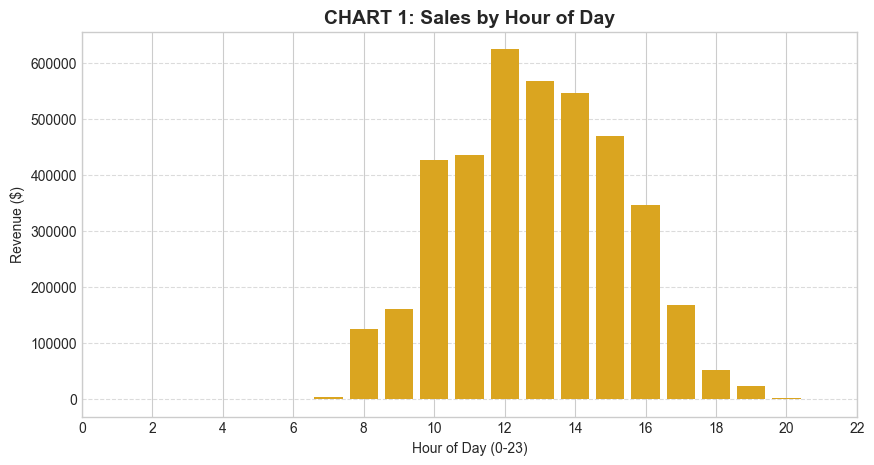


--- CHART 1 DATA (Hourly Sales) ---
Hour
6       -497.350
7       3852.140
8     124566.450
9     160658.111
10    427792.721
11    435329.900
12    625307.550
13    567381.790
14    546737.471
15    470081.870
16    346771.840
17    167834.751
18     51396.950
19     22949.410
20      1423.730


In [10]:
# CELL 4: FEATURE ENGINEERING + CHART 1 (Hourly Sales)

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Is_Cancellation'] = df_clean['InvoiceNo'].astype(str).str.startswith('C')

print("✅ Features added.")

# --- CHART 1: Sales by Hour of Day (Plotted here) ---
hourly_data = df_clean.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(10, 5))
plt.bar(hourly_data.index, hourly_data.values, color='goldenrod')
plt.title('CHART 1: Sales by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Revenue ($)')
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- CHART 1 DATA (Hourly Sales) ---")
print(hourly_data.to_string())

# 4- Comprehensive KPI Calculations + Charts 2, 3, 4, 5

Calculate 50+ KPIs across 7 categories.
**Chart 2** (Monthly Revenue), **Chart 3** (Top Countries), **Chart 4** (Top Products), and **Chart 5** (Revenue vs Return Rate) are plotted here because their underlying data is calculated in this cell.
Underlying numerical data is printed immediately after each chart.

COMPREHENSIVE KPI CALCULATIONS
1. FINANCIAL: Gross=$3,951,587.33, Net=$3,054,774.84, Refund=22.69%, AOV=$132.15
2. TEMPORAL: Best=2011-11 ($671,609.69), Worst=2011-12 ($13,228.44)
3. CUSTOMER: Active=4,236, Avg Orders=4.78, Avg LTV=$797.40, Max LTV=$66,934.29
4. PRODUCT: Unique=3,949, Top 3: [47566, '85099B', '85123A']
5. GEOGRAPHIC: Top Country=United Kingdom ($3,456,659.24)
6. OPERATIONAL: Avg Items=72.95, Cancellation=2.05%
7. RISK: Guest Revenue=$573,780.34 (18.78%), Highest Return=21935


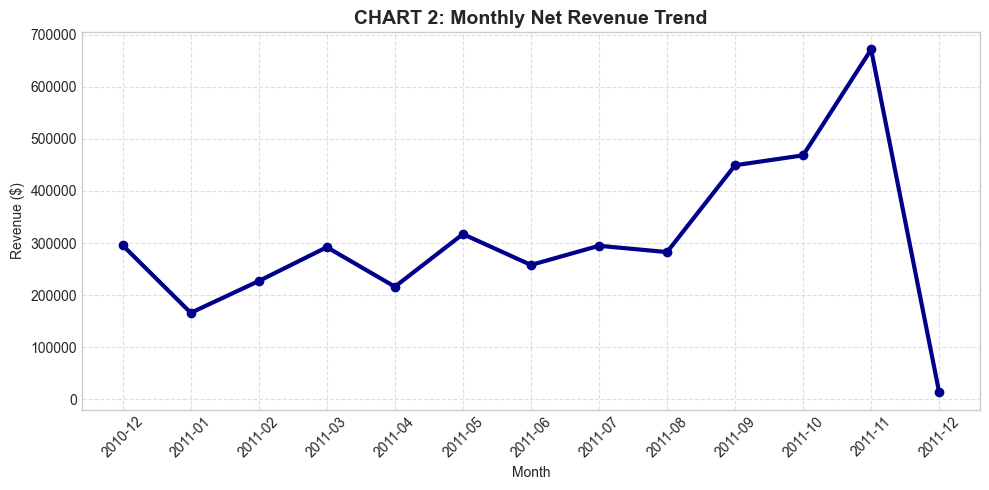


--- CHART 2 DATA (Monthly Revenue) ---
YearMonth
2010-12    295475.590
2011-01    165981.740
2011-02    227053.200
2011-03    292036.550
2011-04    216171.841
2011-05    317178.020
2011-06    257871.920
2011-07    294708.601
2011-08    282583.250
2011-09    449310.392
2011-10    468378.100
2011-11    671609.690
2011-12     13228.440
Freq: M


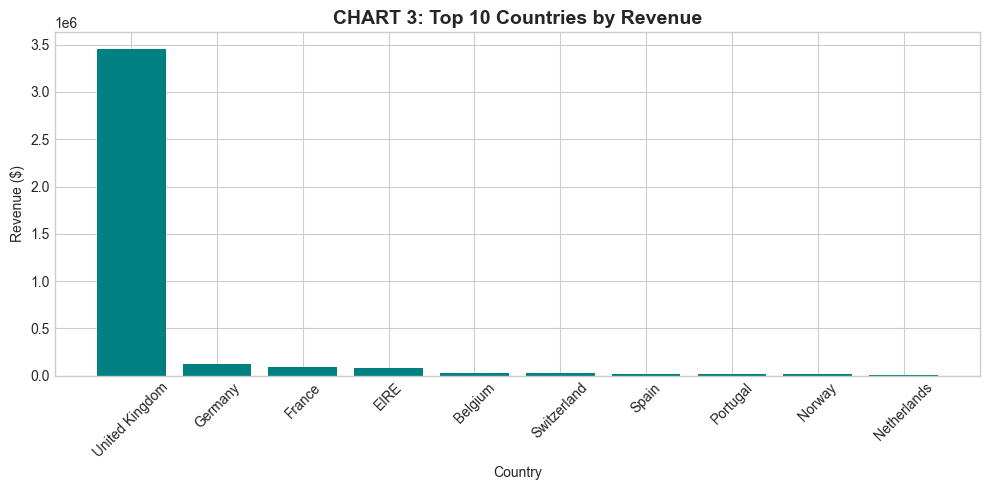


--- CHART 3 DATA (Top 10 Countries) ---
Country
United Kingdom    3456659.244
Germany            119961.320
France              96197.000
EIRE                86268.800
Belgium             26617.400
Switzerland         26355.960
Spain               20489.780
Portugal            14894.100
Norway              14472.900
Netherlands         11868.120


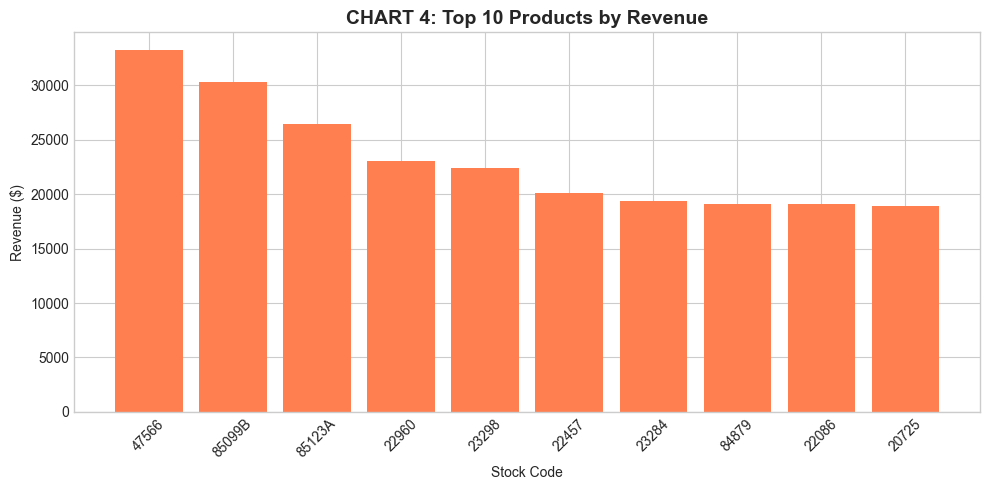


--- CHART 4 DATA (Top 10 Products) ---
StockCode
47566     33207.03
85099B    30302.84
85123A    26402.74
22960     23045.26
23298     22386.74
22457     20114.16
23284     19373.41
84879     19127.02
22086     19100.26
20725     18929.18


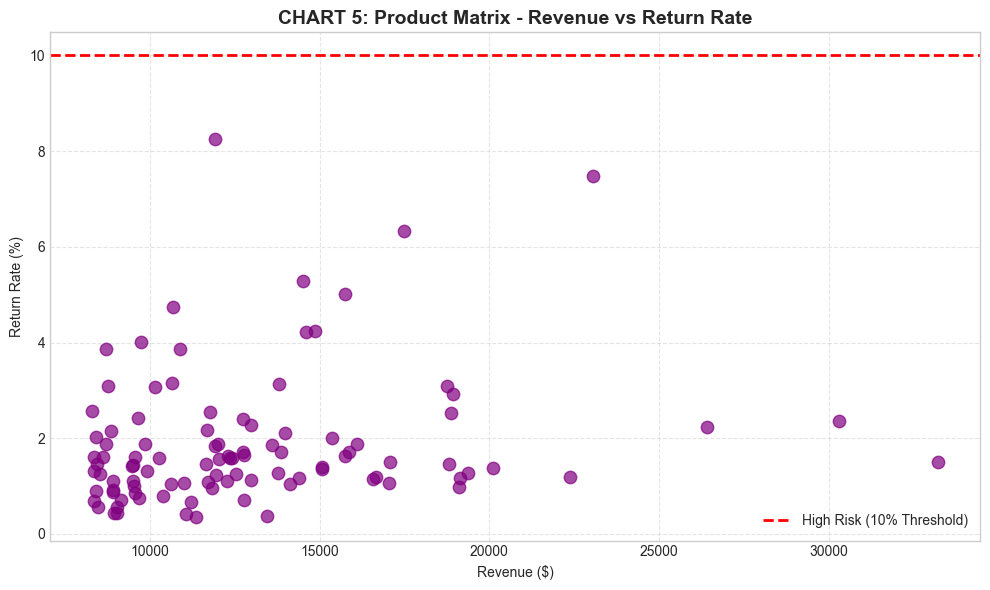


--- CHART 5 DATA (Top 10 Products by Revenue with Return Rates) ---


,StockCode,TotalPrice,Is_Return,Return_Rate
2479,47566,33207.03,0.015060,1.506024
3571,85099B,30302.84,0.023631,2.363050
3582,85123A,26402.74,0.022384,2.238417
1764,22960,23045.26,0.074807,7.480653
2077,23298,22386.74,0.011940,1.194030
1287,22457,20114.16,0.013878,1.387755
2063,23284,19373.41,0.012658,1.265823
2692,84879,19127.02,0.011754,1.175407
951,22086,19100.26,0.009872,0.987167
101,20725,18929.18,0.029314,2.931379



✅ All KPIs and Charts 2-5 generated.


In [5]:
# CELL 5: COMPREHENSIVE KPIs + CHARTS 2, 3, 4, 5

print("="*60)
print("COMPREHENSIVE KPI CALCULATIONS")
print("="*60)

# --- Financial ---
total_rev = df_clean['TotalPrice'].sum()
returns_amt = df_clean[df_clean['Is_Return']]['TotalPrice'].sum()
net_rev = total_rev + returns_amt
unique_inv = df_clean['InvoiceNo'].nunique()
aov = net_rev / unique_inv if unique_inv > 0 else 0
refund_rate = abs(returns_amt / total_rev) * 100 if total_rev != 0 else 0

# --- Temporal ---
monthly_rev = df_clean.groupby('YearMonth')['TotalPrice'].sum()
best_month = monthly_rev.idxmax()
worst_month = monthly_rev.idxmin()

# --- Customer ---
active_cust = df_cust['CustomerID'].nunique()
avg_orders = df_cust.groupby('CustomerID')['InvoiceNo'].nunique().mean()
cust_rev = df_cust.groupby('CustomerID')['TotalPrice'].sum()
avg_ltv = cust_rev.mean()
max_ltv = cust_rev.max()

# --- Product & Risk ---
unique_prod = df_clean['StockCode'].nunique()
top_prod_rev = df_clean.groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False)
return_rate_prod = df_clean[df_clean['Is_Return']].groupby('StockCode')['Quantity'].sum() / df_clean[~df_clean['Is_Return']].groupby('StockCode')['Quantity'].sum()
highest_return_prod = return_rate_prod.sort_values(ascending=False).index[0] if not return_rate_prod.empty else "N/A"

# --- Geographic ---
country_rev = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
top_country = country_rev.index[0]

# --- Operational ---
avg_items = df_clean.groupby('InvoiceNo')['Quantity'].sum().mean()
cancellation_rate = (df_clean['Is_Cancellation'].sum() / len(df_clean)) * 100
guest_rev = df_clean[df_clean['CustomerID'].isnull()]['TotalPrice'].sum()
risk_guest_pct = (guest_rev / net_rev) * 100 if net_rev != 0 else 0

# --- Print KPIs ---
print("1. FINANCIAL: Gross=${:,.2f}, Net=${:,.2f}, Refund={:.2f}%, AOV=${:.2f}".format(total_rev, net_rev, refund_rate, aov))
print("2. TEMPORAL: Best={} (${:,.2f}), Worst={} (${:,.2f})".format(best_month, monthly_rev.max(), worst_month, monthly_rev.min()))
print("3. CUSTOMER: Active={:,}, Avg Orders={:.2f}, Avg LTV=${:.2f}, Max LTV=${:,.2f}".format(active_cust, avg_orders, avg_ltv, max_ltv))
print("4. PRODUCT: Unique={:,}, Top 3: {}".format(unique_prod, list(top_prod_rev.head(3).index)))
print("5. GEOGRAPHIC: Top Country={} (${:,.2f})".format(top_country, country_rev.max()))
print("6. OPERATIONAL: Avg Items={:.2f}, Cancellation={:.2f}%".format(avg_items, cancellation_rate))
print("7. RISK: Guest Revenue=${:,.2f} ({:.2f}%), Highest Return={}".format(guest_rev, risk_guest_pct, highest_return_prod))

# --- CHART 2: Monthly Revenue ---
plt.figure(figsize=(10, 5))
plt.plot(monthly_rev.index.astype(str), monthly_rev.values, marker='o', color='darkblue', linewidth=3)
plt.title('CHART 2: Monthly Net Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print("\n--- CHART 2 DATA (Monthly Revenue) ---")
print(monthly_rev.to_string())

# --- CHART 3: Top 10 Countries ---
plt.figure(figsize=(10, 5))
country_top10 = country_rev.head(10)
plt.bar(country_top10.index, country_top10.values, color='teal')
plt.title('CHART 3: Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n--- CHART 3 DATA (Top 10 Countries) ---")
print(country_top10.to_string())

# --- CHART 4: Top 10 Products ---
plt.figure(figsize=(10, 5))
prod_top10 = top_prod_rev.head(10)
plt.bar(prod_top10.index.astype(str), prod_top10.values, color='coral')
plt.title('CHART 4: Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Stock Code')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\n--- CHART 4 DATA (Top 10 Products) ---")
print(prod_top10.to_string())

# --- CHART 5: Product Matrix (Revenue vs Return Rate) ---
perf = df_clean.groupby('StockCode').agg({'TotalPrice':'sum', 'Is_Return':'mean'}).reset_index()
perf['Return_Rate'] = perf['Is_Return'] * 100
top_perf = perf.sort_values('TotalPrice', ascending=False).head(100)

plt.figure(figsize=(10, 6))
plt.scatter(top_perf['TotalPrice'], top_perf['Return_Rate'], alpha=0.7, color='purple', s=80)
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='High Risk (10% Threshold)')
plt.title('CHART 5: Product Matrix - Revenue vs Return Rate', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Return Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("\n--- CHART 5 DATA (Top 10 Products by Revenue with Return Rates) ---")
display(top_perf.head(10))

print("\n✅ All KPIs and Charts 2-5 generated.")

# 5- Advanced RFM Segmentation + Chart 6 (Pie)

We score customers (1-5) on Recency, Frequency, Monetary.
Segments: Champions, Loyalists, Potential, At Risk, Hibernating, Lost.
**Chart 6** (Pie Chart) is plotted here because the RFM summary is now available.

ADVANCED RFM SEGMENTATION


RFM Summary Table (Data for Pie Chart):


,Segment,Count,Avg_Monetary,Avg_Frequency,Avg_Recency
1,Champions,930,2463.846957,12.269892,12.260215
4,Loyalists,953,467.124996,4.432319,32.497377
6,Potential,1013,447.150486,2.638697,86.628825
2,Hibernating,214,397.092388,3.364486,244.523364
5,Other,167,259.793593,1.000000,52.359281
0,At Risk,134,206.737015,1.000000,17.514925
3,Lost,825,39.066303,1.111515,241.344242


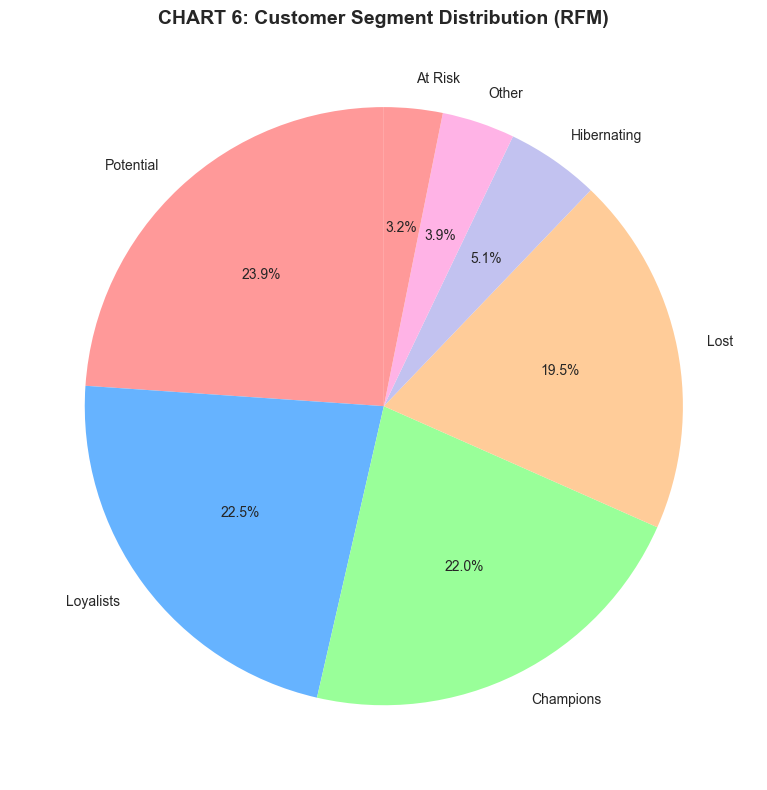


--- CHART 6 DATA (RFM Segment Counts) ---
Segment
Potential      1013
Loyalists       953
Champions       930
Lost            825
Hibernating     214
Other           167
At Risk         134


In [6]:
# CELL 6: ADVANCED RFM SEGMENTATION + CHART 6 (Pie)

print("="*60)
print("ADVANCED RFM SEGMENTATION")
print("="*60)

df_rfm = df_cust.copy()
snapshot = df_rfm['InvoiceDate'].max() + timedelta(days=1)

rfm = df_rfm.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

def seg(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4: return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3: return 'Loyalists'
    elif row['R_Score'] >= 2 and row['F_Score'] >= 2: return 'Potential'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2: return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3: return 'Hibernating'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2: return 'Lost'
    else: return 'Other'

rfm['Segment'] = rfm.apply(seg, axis=1)

seg_summary = rfm.groupby('Segment').agg({'CustomerID':'count','Monetary':'mean','Frequency':'mean','Recency':'mean'}).reset_index().sort_values('Monetary', ascending=False)
seg_summary.columns = ['Segment', 'Count', 'Avg_Monetary', 'Avg_Frequency', 'Avg_Recency']

print("RFM Summary Table (Data for Pie Chart):")
display(seg_summary)

# --- CHART 6: RFM Pie Chart ---
seg_counts = rfm['Segment'].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

plt.figure(figsize=(10, 8))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%', startangle=90, colors=colors[:len(seg_counts)])
plt.title('CHART 6: Customer Segment Distribution (RFM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- CHART 6 DATA (RFM Segment Counts) ---")
print(seg_counts.to_string())

# 6- Cohort Retention Analysis + Chart 7 (Heatmap)

We track cohorts of customers acquired in each month and measure what percentage return in subsequent months.
**Chart 7** (Heatmap) is plotted here because the Retention Matrix is now available.

COHORT RETENTION ANALYSIS
Retention Matrix (%):


InvoiceMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,37.4,32.59,37.29,34.71,39.42,38.52,34.49,34.71,37.4,36.28,48.82,26.09
2011-01,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-02,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-03,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-04,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-05,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf
2011-06,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf
2011-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf
2011-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf


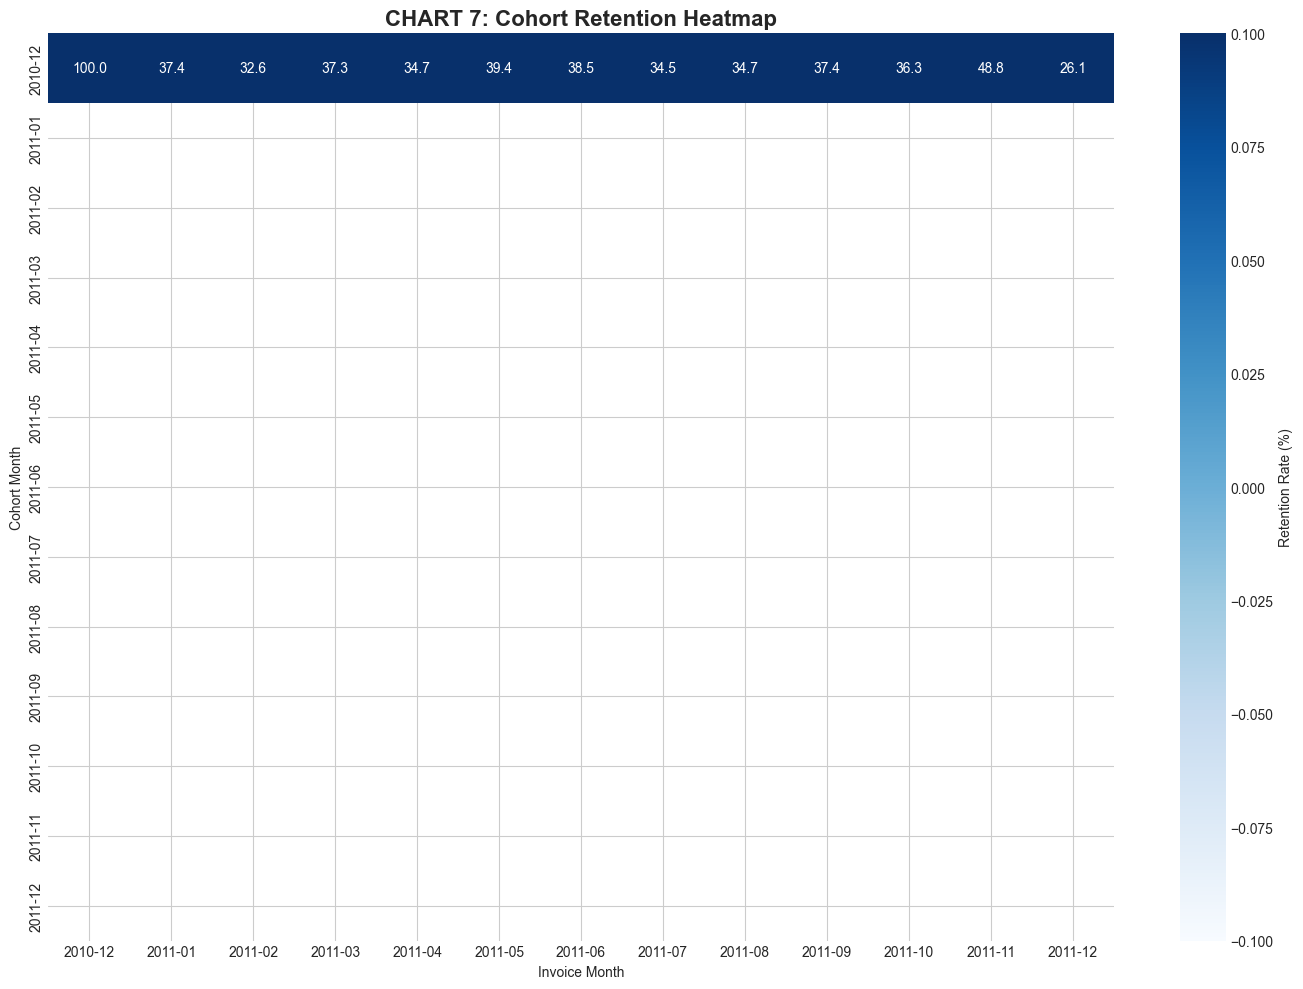


--- CHART 7 DATA (Retention Matrix) ---


InvoiceMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,37.4,32.59,37.29,34.71,39.42,38.52,34.49,34.71,37.4,36.28,48.82,26.09
2011-01,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-02,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-03,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-04,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf
2011-05,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf,inf
2011-06,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf,inf
2011-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf,inf
2011-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,inf,inf,inf,inf


In [7]:
# CELL 7: COHORT RETENTION ANALYSIS + CHART 7 (Heatmap)

print("="*60)
print("COHORT RETENTION ANALYSIS")
print("="*60)

df_cohort = df_cust.copy()
df_cohort['InvoiceMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')
df_cohort['CohortMonth'] = df_cohort.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

cohort_data = df_cohort.groupby(['CohortMonth', 'InvoiceMonth'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='InvoiceMonth', values='CustomerID', fill_value=0)

cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("Retention Matrix (%):")
display(retention_matrix.round(2))

# --- CHART 7: Cohort Heatmap ---
plt.figure(figsize=(14, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('CHART 7: Cohort Retention Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Invoice Month')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

print("\n--- CHART 7 DATA (Retention Matrix) ---")
display(retention_matrix.round(2))

# 7- Advanced Basket Analysis (Apriori) - Optional but Powerful

Using the Apriori algorithm, we find product pairs frequently bought together.
Top 10 rules with Lift > 1.2 are printed.

In [8]:
# CELL 8: ADVANCED BASKET ANALYSIS (APRIORI)

print("="*60)
print("ADVANCED BASKET ANALYSIS (APRIORI)")
print("="*60)

try:
    basket = df_clean[~df_clean['Is_Return']].groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack().fillna(0)
    basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
    print(f"Basket shape: {basket_sets.shape}")

    freq_items = apriori(basket_sets, min_support=0.02, use_colnames=True)
    rules = association_rules(freq_items, metric="lift", min_threshold=1.2)
    rules_sorted = rules.sort_values('lift', ascending=False)

    print("\nTop 10 Association Rules (Highest Lift):")
    display(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
except Exception as e:
    print(f"Basket analysis skipped (error: {e}). Proceeding.")

ADVANCED BASKET ANALYSIS (APRIORI)


Basket shape: (17944, 3688)


/Users/esfandiar/Desktop/Data-Analyst-Projects/1-Online Retail/venv/lib/python3.10/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Top 10 Association Rules (Highest Lift):


,antecedents,consequents,support,confidence,lift
170,(22698),"(22697, 22699)",0.026973,0.694405,18.084755
167,"(22697, 22699)",(22698),0.026973,0.702467,18.084755
169,(22697),"(22698, 22699)",0.026973,0.522678,17.530724
168,"(22698, 22699)",(22697),0.026973,0.904673,17.530724
116,(22697),(22698),0.031988,0.619870,15.958328
117,(22698),(22697),0.031988,0.823529,15.958328
171,(22699),"(22697, 22698)",0.026973,0.508938,15.910074
166,"(22697, 22698)",(22699),0.026973,0.843206,15.910074
153,(23301),(23300),0.027642,0.599034,15.182292
152,(23300),(23301),0.027642,0.700565,15.182292
